# GRB and Kilonova Mass-Plane Diagnostics

Applies the Gottlieb et al. ([2023](https://arxiv.org/abs/2309.00038), [2024](https://arxiv.org/abs/2411.13657v2)) GRB and kilonova classification framework to COMPAS Model A (Broekgaarden et al. 2021, arXiv:2103.02608). Cosmology pinned to Planck 2015 ($H_0 = 67.74$ km/s/Mpc, $\Omega_m = 0.3089$) to match COMPAS `FastCosmicIntegration`. All disk-mass GRB rates assume 100 percent jet launching above threshold and are upper bounds (Gottlieb 2023). NS gravitational masses are quantile-remapped to the Alsing, Silva and Berti (2018, MNRAS 478, 1377) Galactic double-Gaussian fit (closes the Fryer 2012 rapid-engine gap near $1.7\,M_\odot$; Mandel and Muller 2020).

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm, to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

from grb_physics import (foucart_disk_mass, M_CRIT_BNS, Q_THRESH_BNS,
                          MDISK_SHORT, MDISK_LONG, M_TOV, M_THRESH,
                          EOS_MODELS, mcrit_to_r14,
                          MISALIGNMENT_SYSTEMATIC_FACTOR,
                          effective_aligned_spin, ns_radius_from_eos,
                          remap_ns_masses_double_gaussian,
                          NS_REMAP_MU1, NS_REMAP_MU2)
from grb_classify import (classify_bns_2023, classify_bns_2024, classify_bhns,
                           classify_grid, classify_formation_channels,
                           bns_boundary_lines)
from grb_rates import (compute_merger_rate, calibrate_mean_mass_evolved,
                        formation_efficiency, marginalize_bh_spin,
                        rate_label,
                        beamed_rate, OBSERVED_SGRB_RATES,
                        wanderman_piran_2015_Rz,
                        check_dPdlogZ_normalization, CLASS_THETA_J,
                        apply_bhns_misalignment)
from grb_io import (load_bns, load_bhns, load_bns_with_channels,
                     load_bns_with_kicks, load_bhns_with_kicks,
                     read_expected_local_rate,
                     verify_shared_metallicity_prior,
                     METALLICITY_GRID,
                     OBSERVED_GW_EVENTS,
                     DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)

# Project palette (CLAUDE.md scientific plotting standards).
C_SB_BLUE  = '#06B6D4'
C_LB_HMNS  = '#DC2626'
C_LB_DISK  = '#DC2626'
C_FAINT    = '#F59E0B'
C_NO_GRB   = '#334155'
C_FAINT_BH = '#F59E0B'
C_LONG_BH  = '#DC2626'
C_OBS      = '#6B21A8'
C_GUIDE    = '#94A3B8'
C_TEXT     = '#0F172A'
C_BOX_EDGE = '#CBD5E1'

# ApJ rcParams applied globally so every figure inherits the same body
# font, tick style, and serif math (CLAUDE.md plotting standards).
APJ_RCPARAMS = {
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'savefig.format':      'pdf',
    'font.size':           8,
    'font.family':         'serif',
    'mathtext.fontset':    'cm',
    'axes.linewidth':      0.7,
    'axes.labelsize':      9,
    'axes.titlesize':      9,
    'xtick.labelsize':     7,
    'ytick.labelsize':     7,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'legend.fontsize':     7,
    'legend.frameon':      True,
    'legend.framealpha':   0.92,
    'lines.linewidth':     1.0,
}
plt.rcParams.update(APJ_RCPARAMS)

A_BH_FID = 0.5
M_HMNS_SPLIT = 1.2 * M_TOV

# COMPAS Model A maximum NS gravitational mass (Broekgaarden+ 2021,
# arXiv:2103.02608; their fiducial M_NS_max = 2.5 Msun, Models J/K = 2.0/3.0).
NS_MAX_BNS = 2.5

# Mass-plane shared plot constants. GRID_COLORS is indexed by classify_grid
# integer labels (0 = unclassified, 1-6 see grb_classify.GRID_CLASS_LABELS).
cmap_hex   = 'Greys'
grid_colors = [C_NO_GRB, C_FAINT, C_LB_HMNS, C_SB_BLUE, C_LB_DISK,
               C_FAINT_BH, C_LONG_BH]
norm_grid  = BoundaryNorm(np.arange(-0.5, 7.5, 1), len(grid_colors))
TINT_ALPHA = 0.22
cmap_grid_tint = ListedColormap(
    [to_rgba(c, 0.0 if c == C_NO_GRB else TINT_ALPHA) for c in grid_colors])

# Load BNS (with channels + kicks for later sections).
bns_ch = load_bns_with_channels()
bns_k  = load_bns_with_kicks()

# Apply Alsing, Silva and Berti (2018) double-Gaussian remap globally so every
# downstream BNS figure and rate sees the same masses.
_m1_raw_bns, _m2_raw_bns = bns_ch['m1'].copy(), bns_ch['m2'].copy()
bns_ch['m1'], bns_ch['m2'] = remap_ns_masses_double_gaussian(
    _m1_raw_bns, _m2_raw_bns,
    weights=bns_ch['weights'], rng=np.random.default_rng(42))
bns_k['m1'],  bns_k['m2']  = bns_ch['m1'], bns_ch['m2']

m1_bns, m2_bns = bns_ch['m1'], bns_ch['m2']
w_bns     = bns_ch['weights']
Z_bns     = bns_ch['metallicity']
delay_bns = bns_ch['delay_time']
n_bns     = bns_ch['n_merging']
M_tot     = m1_bns + m2_bns
q_bns     = m1_bns / m2_bns

# Vectorized remap diagnostics: stack the two component arrays and count
# raw/remapped systems in the [1.65, 1.80] Msun rapid-engine gap.
gap_lo, gap_hi = 1.65, 1.80
_raw   = np.concatenate([_m1_raw_bns, _m2_raw_bns])
_new   = np.concatenate([m1_bns, m2_bns])
_n_gap = ((_raw >= gap_lo) & (_raw <= gap_hi)).sum()
_n_new = ((_new >= gap_lo) & (_new <= gap_hi)).sum()
print(f"BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  "
      f"raw={int(_n_gap):,}  remap={int(_n_new):,}  "
      f"max NS = {_new.max():.3f}  M_TOV = {M_TOV:.2f}")
assert _new.max() <= M_TOV + 1e-6, "remapped NS mass exceeds M_TOV"
assert bool(np.all(m1_bns >= m2_bns)), "m1 >= m2 invariant broken after remap"

# BNS classification.
cls24 = classify_bns_2024(m1_bns, m2_bns)
sbGRB_blue   = cls24['sbGRB + blue KN']
lbGRB_hmns   = cls24['lbGRB + red KN (HMNS)']
lbGRB_disk   = cls24['lbGRB + red KN (disk)']
bns_faint_lb = cls24['Faint lbGRB']

cls23 = classify_bns_2023(m1_bns, m2_bns)
short_typeI_23  = cls23['Short Type-I']
short_typeII_23 = cls23['Short Type-II']
long_cbGRB_23   = cls23['Long cbGRB']

# Load BHNS (with kicks for offsets) and classify with Foucart 2018 disk mass.
bhns = load_bhns_with_kicks()
BH, NS_bh  = bhns['M_BH'], bhns['M_NS']
w_bhns     = bhns['weights']
Z_bhns     = bhns['metallicity']
delay_bhns = bhns['delay_time']
n_bhns     = bhns['n_merging']

cbhns = classify_bhns(BH, NS_bh, a_BH=A_BH_FID)
M_disk_bhns   = cbhns['M_disk']
bhns_no_grb   = cbhns['No GRB']
bhns_faint_lb = cbhns['Short cbGRB']
bhns_long     = cbhns['Long cbGRB']

v_sys_bns  = bns_k['v_sys']
v_sys_bhns = bhns['v_sys']

# Vectorized class summary: mask matrix (n_class, N) -> weighted counts.
def _summary(name, masks_dict, w, n):
    arr = np.stack(list(masks_dict.values()))
    counts = (arr * w).sum(-1) / w.sum() * 100
    raw    = arr.sum(-1)
    print(f"\n{name}: {n:,} merging systems")
    for (lbl, _), pct, n_raw in zip(masks_dict.items(), counts, raw):
        print(f"  {lbl:38s}: {int(n_raw):>7,}  ({pct:.1f}% weighted)")

_summary('BNS', {
    'sbGRB + blue KN (long-lived HMNS)':    sbGRB_blue,
    'lbGRB + red KN  (short-lived HMNS)':   lbGRB_hmns,
    'lbGRB + red KN  (massive disk)':       lbGRB_disk,
    'Faint lbGRB    (small disk / prompt)': bns_faint_lb,
}, w_bns, n_bns)

_summary(f'BHNS (a_BH = {A_BH_FID})', {
    'lbGRB + red KN (massive disk)': bhns_long,
    'Faint lbGRB    (small disk)':   bhns_faint_lb,
    'No GRB / KN    (NS swallowed)': bhns_no_grb,
}, w_bhns, n_bhns)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  raw=21,589  remap=35,490  max NS = 2.200  M_TOV = 2.20

BNS: 233,137 merging systems
  sbGRB + blue KN (long-lived HMNS)     :  34,366  (19.8% weighted)
  lbGRB + red KN  (short-lived HMNS)    : 106,719  (31.3% weighted)
  lbGRB + red KN  (massive disk)        :  36,039  (20.9% weighted)
  Faint lbGRB    (small disk / prompt)  :  56,013  (27.9% weighted)

BHNS (a_BH = 0.5): 1,525,553 merging systems
  lbGRB + red KN (massive disk)         :   5,108  (2.8% weighted)
  Faint lbGRB    (small disk)           :  76,993  (11.5% weighted)
  No GRB / KN    (NS swallowed)         : 1,117,851  (67.2% weighted)


/Users/josephrodriguez/research visualization/grb_physics.py:661: UserWarning: Foucart (2018) formula applied to 410646 systems with Q > 7 (max Q=29.0); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(M_BH, M_NS, a_BH=a_BH,


## 1. Mass Plane, BNS and BHNS

Combined $M_1$ vs $M_2$ diagrams for COMPAS Model A. The BHNS panel uses Foucart, Hinderer and Nissanke (2018, PRD 98, 081501) disk-mass classes at $a_\mathrm{BH} = 0.5$; the BNS panel reproduces and extends Gottlieb et al. (2024, Figure 3). The greyscale hexbin shows STROOPWAFEL-weighted population density on a log scale; faint colored tints mark classification regions; boundary contours overlay the data layer.

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_76553/1277878899.py:10: UserWarning: classify_grid: R_1p4_km not specified; BHNS branch inherits foucart_disk_mass default R_1p4_km=12.0 km, so class 6 (lbGRB + red KN, massive disk) is implicitly EOS-dependent.  Pass R_1p4_km explicitly (e.g. EOS_MODELS['SFHo']['R_1p4']) to suppress this warning.
  cls_bhns = classify_grid(M1G_bhns, M2G_bhns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
/Users/josephrodriguez/research visualization/grb_physics.py:661: UserWarning: Foucart (2018) formula applied to 158725 systems with Q > 7 (max Q=16.0); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(M_BH, M_NS, a_BH=a_BH,
/Users/josephrodriguez/research visualization/grb_physics.py:661: UserWarning: Foucart (2018) formula applied to 33976 systems with Q > 7 (max Q=22.2); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(M_BH, M_NS, a_BH=a_BH,


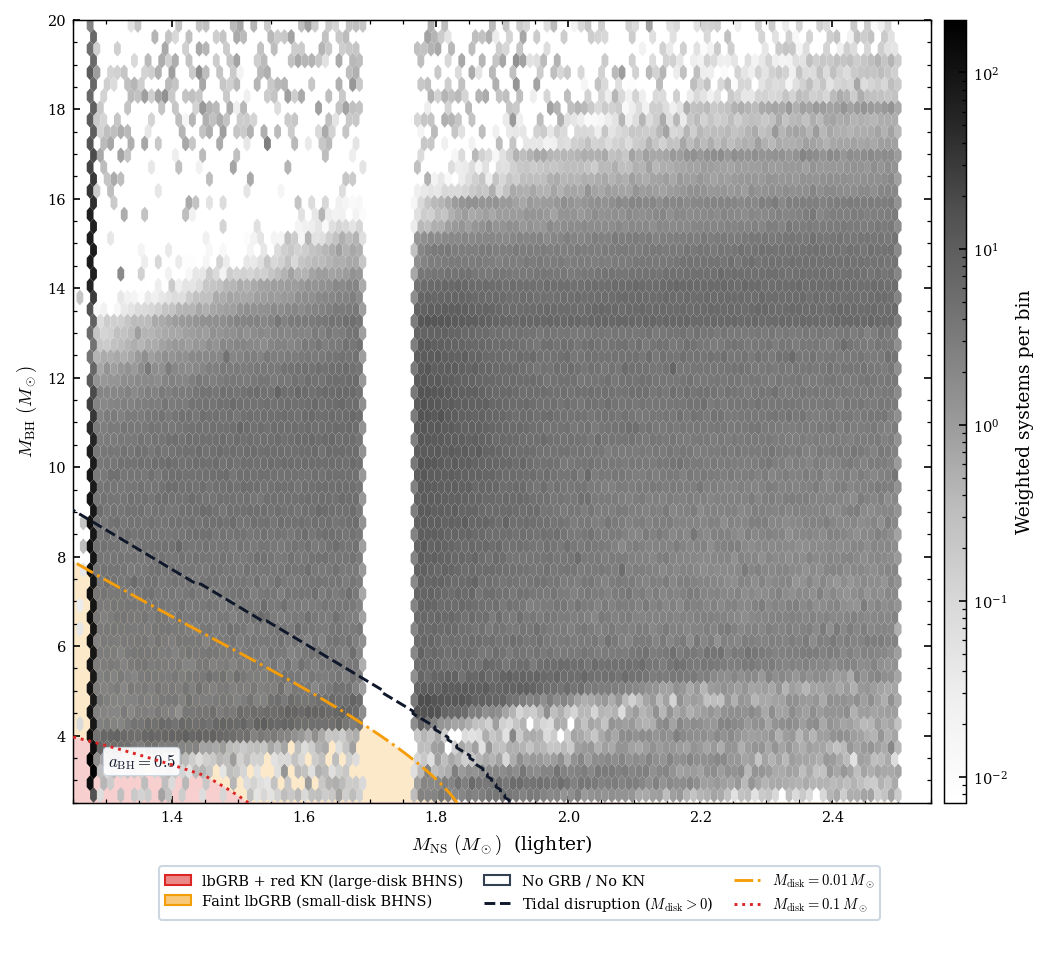

In [13]:
# BHNS classification grid (faint underlay).
# Use NS_MAX_BNS (Broekgaarden+ 2021 M_NS_max = 2.5 Msun) for the BNS/BHNS
# boundary, matching the COMPAS run configuration.
M2_LO_BHNS, M2_HI_BHNS = 1.25, 2.55
M1_LO_BHNS, M1_HI_BHNS = NS_MAX_BNS, 20.0

m2_arr_bhns = np.linspace(M2_LO_BHNS, M2_HI_BHNS, 700)
m1_arr_bhns = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 600)
M2G_bhns, M1G_bhns = np.meshgrid(m2_arr_bhns, m1_arr_bhns)
cls_bhns = classify_grid(M1G_bhns, M2G_bhns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
cls_bhns_masked = np.ma.array(cls_bhns, mask=(M2G_bhns < 0.8))

# Foucart (2018) disk-mass contours for the boundary lines.
_MBH_c = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 300)
_MNS_c = np.linspace(0.9, M2_HI_BHNS, 250)
_MNSg, _MBHg = np.meshgrid(_MNS_c, _MBH_c)
_disk_g = foucart_disk_mass(_MBHg, _MNSg, a_BH=A_BH_FID)
_dg_safe = np.where(_disk_g > 0, _disk_g, np.nan)

fig_bhns = plt.figure(figsize=(7.0, 6.8))
gs = GridSpec(2, 2, height_ratios=[1, 0.14],
              width_ratios=[1, 0.025], hspace=0.08, wspace=0.03,
              figure=fig_bhns,
              left=0.10, right=0.95, top=0.97, bottom=0.06)
ax  = fig_bhns.add_subplot(gs[0, 0])
cax = fig_bhns.add_subplot(gs[0, 1])
lax = fig_bhns.add_subplot(gs[1, :])
lax.axis('off')

ax.pcolormesh(m2_arr_bhns, m1_arr_bhns, cls_bhns_masked,
              cmap=cmap_grid_tint, norm=norm_grid, shading='nearest',
              rasterized=True, zorder=0)

hb_bh = ax.hexbin(NS_bh, BH, C=w_bhns, reduce_C_function=np.sum,
                  gridsize=120, cmap=cmap_hex, mincnt=1, norm=LogNorm(),
                  edgecolors='none', linewidths=0.2, zorder=2)

ax.contour(_MNSg, _MBHg, (_disk_g > 0).astype(float), levels=[0.5],
           colors=C_TEXT, linewidths=1.4, linestyles='--', zorder=4)
ax.contour(_MNSg, _MBHg, _dg_safe, levels=[MDISK_SHORT, MDISK_LONG],
           colors=[C_FAINT, C_LB_DISK], linewidths=1.4,
           linestyles=['-.', ':'], zorder=4)

ax.text(0.04, 0.04, rf'$a_{{\mathrm{{BH}}}} = {A_BH_FID}$',
        color=C_TEXT, transform=ax.transAxes, va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', fc='white',
                  ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_\mathrm{NS}\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_\mathrm{BH}\ (M_\odot)$')
ax.set_xlim(M2_LO_BHNS, M2_HI_BHNS)
ax.set_ylim(M1_LO_BHNS, M1_HI_BHNS)
ax.set_axisbelow(True)

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_LONG_BH, _pa), ec=C_LONG_BH, lw=1.0,
          label='lbGRB + red KN (large-disk BHNS)'),
    Patch(fc=to_rgba(C_FAINT_BH, _pa), ec=C_FAINT_BH, lw=1.0,
          label='Faint lbGRB (small-disk BHNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_TEXT, lw=1.4, ls='--',
           label=r'Tidal disruption ($M_\mathrm{disk} > 0$)'),
    Line2D([0], [0], color=C_FAINT, lw=1.4, ls='-.',
           label=r'$M_\mathrm{disk} = 0.01\,M_\odot$'),
    Line2D([0], [0], color=C_LB_DISK, lw=1.4, ls=':',
           label=r'$M_\mathrm{disk} = 0.1\,M_\odot$'),
]
lax.legend(handles=handles, loc='center', ncol=3,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.8, columnspacing=1.4, labelspacing=0.4,
           borderaxespad=0.0)

cbar = fig_bhns.colorbar(hb_bh, cax=cax, orientation='vertical')
cbar.set_label(r'Weighted systems per bin')

fig_bhns.savefig('Plots/mass_plane_bhns.png', dpi=300)
fig_bhns.savefig('Plots/mass_plane_bhns.pdf')
plt.show()


**BHNS mass plane (Section 1 supporting panel).** Greyscale hexbin: STROOPWAFEL-weighted population density (`C=w_bhns`, `reduce_C_function=np.sum`); colored tints are Foucart, Hinderer and Nissanke (2018) disk-mass classes at $a_\mathrm{BH} = 0.5$ (red: lbGRB + red KN, $M_\mathrm{disk} \geq 0.1\,M_\odot$; amber: Faint lbGRB, $0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$; No GRB region untinted). Boundaries: dashed dark for tidal-disruption locus ($M_\mathrm{disk} > 0$), dash-dot amber for $M_\mathrm{disk} = 0.01\,M_\odot$, dotted red for $M_\mathrm{disk} = 0.1\,M_\odot$. Foucart (2018) is calibrated for $\chi_\mathrm{BH} \in [-0.5, 0.9]$, $Q \in [1, 7]$; the BHNS NS masses are not remapped (rapid-engine gap visible at $\sim 1.7\,M_\odot$); the population-level misalignment correction is rate-level, not sample-level (`apply_bhns_misalignment`).

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_76553/4195604501.py:11: UserWarning: classify_grid: R_1p4_km not specified; BHNS branch inherits foucart_disk_mass default R_1p4_km=12.0 km, so class 6 (lbGRB + red KN, massive disk) is implicitly EOS-dependent.  Pass R_1p4_km explicitly (e.g. EOS_MODELS['SFHo']['R_1p4']) to suppress this warning.
  cls_bns = classify_grid(M1G_bns, M2G_bns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)


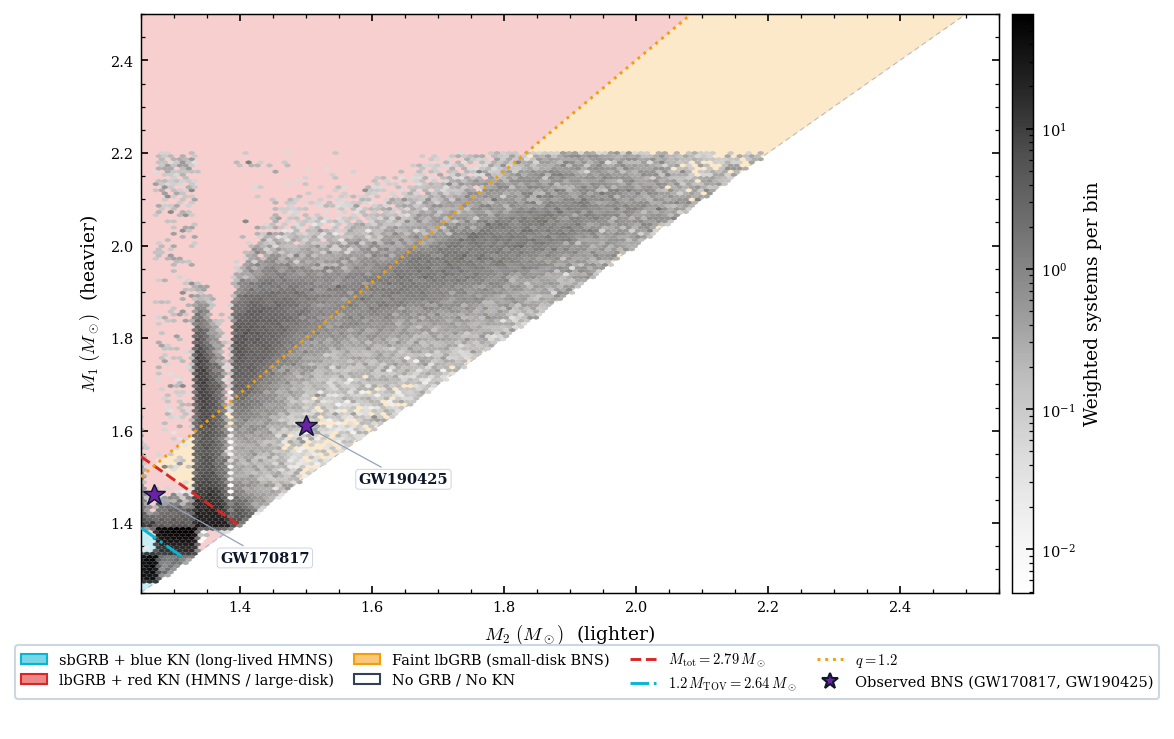

In [14]:
# BNS classification grid (faint underlay), square 0.002 Msun spacing.
M2_LO_BNS, M2_HI_BNS = 1.25, 2.55
M1_LO_BNS, M1_HI_BNS = 1.25, NS_MAX_BNS
DM_GRID_BNS = 0.002

n2 = int(round((M2_HI_BNS - M2_LO_BNS) / DM_GRID_BNS)) + 1
n1 = int(round((M1_HI_BNS - M1_LO_BNS) / DM_GRID_BNS)) + 1
m2_arr_bns = np.linspace(M2_LO_BNS, M2_HI_BNS, n2)
m1_arr_bns = np.linspace(M1_LO_BNS, M1_HI_BNS, n1)
M2G_bns, M1G_bns = np.meshgrid(m2_arr_bns, m1_arr_bns)
cls_bns = classify_grid(M1G_bns, M2G_bns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
cls_bns_masked = np.ma.array(cls_bns, mask=(M1G_bns < M2G_bns))

fig_bns = plt.figure(figsize=(7.0, 5.2))
gs = GridSpec(2, 2, height_ratios=[1, 0.18],
              width_ratios=[1, 0.025], hspace=0.08, wspace=0.03,
              figure=fig_bns,
              left=0.10, right=0.95, top=0.97, bottom=0.06)
ax  = fig_bns.add_subplot(gs[0, 0])
cax = fig_bns.add_subplot(gs[0, 1])
lax = fig_bns.add_subplot(gs[1, :])
lax.axis('off')

ax.pcolormesh(m2_arr_bns, m1_arr_bns, cls_bns_masked,
              cmap=cmap_grid_tint, norm=norm_grid, shading='nearest',
              rasterized=True, zorder=0)

hb_ns = ax.hexbin(m2_bns, m1_bns, C=w_bns, reduce_C_function=np.sum,
                  gridsize=120, cmap=cmap_hex, mincnt=1, norm=LogNorm(),
                  edgecolors='none', linewidths=0.2, zorder=2)

_m2 = np.linspace(M2_LO_BNS, M2_HI_BNS, 500)
_bdy = bns_boundary_lines(_m2, m1_lim=(M1_LO_BNS, M1_HI_BNS))
ax.plot(*_bdy['M_tot'], color=C_LB_HMNS, lw=1.4, ls='--', zorder=4)
ax.plot(*_bdy['HMNS'],  color=C_SB_BLUE, lw=1.4, ls='-.', zorder=4)
ax.plot(*_bdy['q'],     color=C_FAINT,   lw=1.4, ls=':',  zorder=4)

diag_lo, diag_hi = M2_LO_BNS, min(M2_HI_BNS, M1_HI_BNS)
ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi],
        color=C_GUIDE, lw=0.6, ls=(0, (4, 3)), alpha=0.6, zorder=1)

# Observed BNS GW events (Abbott+ 2019 PRX 9, 011001 low-spin medians;
# Abbott+ 2020 ApJL 892, L3 low-spin medians).
for name, ev in OBSERVED_GW_EVENTS.items():
    m2v, m1v = ev['M2'], ev['M1']
    ax.plot(m2v, m1v, marker='*', ms=11, mec=C_TEXT, mfc=C_OBS,
            mew=0.7, zorder=12)
    dx, dy = (0.10, -0.12) if name == 'GW170817' else (0.08, -0.10)
    ax.annotate(name, xy=(m2v, m1v), xytext=(m2v + dx, m1v + dy),
                fontsize=7, color=C_TEXT, fontweight='bold',
                ha='left', va='top',
                arrowprops=dict(arrowstyle='->', color=C_GUIDE, lw=0.6),
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_2\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_1\ (M_\odot)$  (heavier)')
ax.set_xlim(M2_LO_BNS, M2_HI_BNS)
ax.set_ylim(M1_LO_BNS, M1_HI_BNS)
ax.set_axisbelow(True)

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_SB_BLUE, _pa), ec=C_SB_BLUE, lw=1.0,
          label='sbGRB + blue KN (long-lived HMNS)'),
    Patch(fc=to_rgba(C_LB_HMNS, _pa), ec=C_LB_HMNS, lw=1.0,
          label='lbGRB + red KN (HMNS / large-disk)'),
    Patch(fc=to_rgba(C_FAINT, _pa), ec=C_FAINT, lw=1.0,
          label='Faint lbGRB (small-disk BNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_LB_HMNS, lw=1.4, ls='--',
           label=rf'$M_{{\mathrm{{tot}}}} = {M_THRESH:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_SB_BLUE, lw=1.4, ls='-.',
           label=rf'$1.2\,M_{{\mathrm{{TOV}}}} = {M_HMNS_SPLIT:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_FAINT, lw=1.4, ls=':', label=r'$q = 1.2$'),
    Line2D([0], [0], marker='*', color='w', mfc=C_OBS, mec=C_TEXT,
           ms=8, lw=0, label='Observed BNS (GW170817, GW190425)'),
]
lax.legend(handles=handles, loc='center', ncol=4,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.8, columnspacing=1.4, labelspacing=0.4,
           borderaxespad=0.0)

cbar = fig_bns.colorbar(hb_ns, cax=cax, orientation='vertical')
cbar.set_label(r'Weighted systems per bin')

fig_bns.savefig('Plots/mass_plane_bns.png', dpi=300)
fig_bns.savefig('Plots/fig1_bns_mass_plane_modelA.pdf')
plt.show()


**Figure 1. BNS mass plane, COMPAS Model A.** Greyscale hexbin: STROOPWAFEL-weighted population density. Tints: Gottlieb et al. (2024) regions (cyan: sbGRB + blue KN, $M_\mathrm{tot} < 1.2\,M_\mathrm{TOV}$; red: lbGRB + red KN, short-lived HMNS or large-disk prompt collapse; amber: Faint lbGRB, $q < 1.2$ above $M_\mathrm{thresh}$). Boundaries: dashed red $M_\mathrm{tot} = M_\mathrm{thresh} = 2.79\,M_\odot$, dash-dot cyan $1.2\,M_\mathrm{TOV} = 2.64\,M_\odot$, dotted amber $q = 1.2$. Purple stars: GW170817, GW190425 (low-spin medians). $M_\mathrm{thresh} = 1.27\,M_\mathrm{TOV}$ is a Gottlieb (2023) fiducial; the $1.2\,M_\mathrm{TOV}$ HMNS split is a code heuristic (Margalit and Metzger 2017).

## 2. Component Mass Distributions by GRB Class

Weighted histograms of $M_1$, $M_2$, $M_\mathrm{tot}$, and $q$ per Gottlieb (2024) GRB class. Shaded bands are weighted Poisson uncertainties $\sigma_i = \sqrt{\sum w_i^2}$ (CLAUDE.md). The Fryer (2012) rapid SN engine produces a narrow NS distribution near $1.26$-$1.28\,M_\odot$; class fractions near the $1.2\,M_\mathrm{TOV}$ HMNS split are sensitive to this prescription.

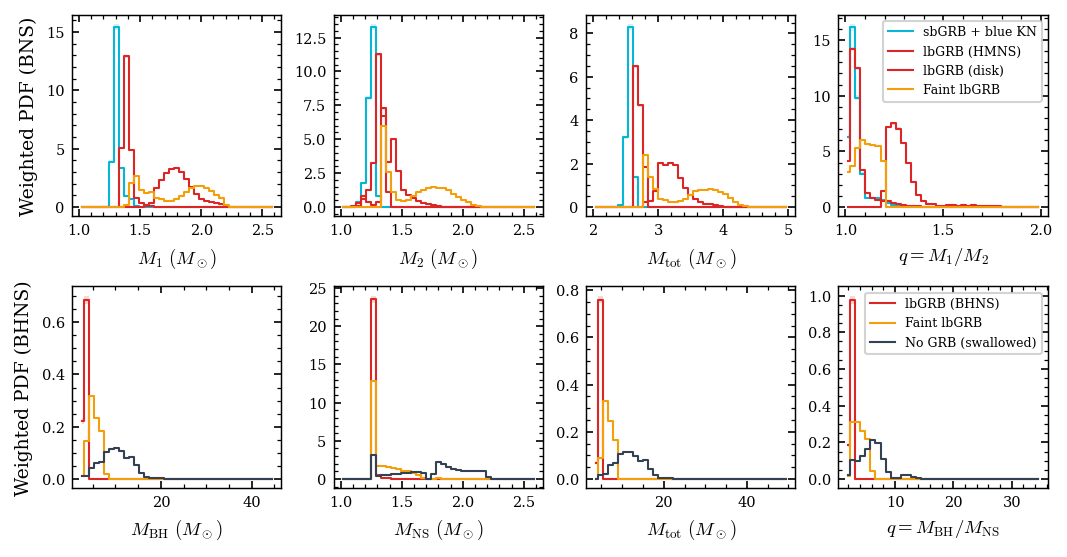

In [15]:
# Vectorized weighted histogram with Poisson sigma_i = sqrt(sum w^2_i).
def _weighted_hist_pdf(data, mask, w, bins):
    if not mask.any():
        return None
    sub_d, sub_w = data[mask], w[mask]
    mu,    _ = np.histogram(sub_d, bins=bins, weights=sub_w)
    var,   _ = np.histogram(sub_d, bins=bins, weights=sub_w * sub_w)
    binw  = np.diff(bins)
    norm  = sub_w.sum() * binw
    return (0.5 * (bins[:-1] + bins[1:]),
            mu / norm,
            np.sqrt(var) / norm)

bns_classes = [
    ('sbGRB + blue KN', sbGRB_blue,    C_SB_BLUE),
    ('lbGRB (HMNS)',    lbGRB_hmns,    C_LB_HMNS),
    ('lbGRB (disk)',    lbGRB_disk,    C_LB_DISK),
    ('Faint lbGRB',     bns_faint_lb,  C_FAINT),
]
bhns_classes = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH),
    ('Faint lbGRB',        bhns_faint_lb, C_FAINT_BH),
    ('No GRB (swallowed)', bhns_no_grb,   C_NO_GRB),
]

bins_m  = np.linspace(1.0, 2.6, 40)
bins_mt = np.linspace(2.0, 5.0, 40)
bins_q  = np.linspace(1.0, 2.0, 40)
bins_bh = np.linspace(2, 45, 40)

fig, axes = plt.subplots(2, 4, figsize=(7.0, 3.6), constrained_layout=True)

bns_panels = [
    (m1_bns, bins_m,  r'$M_1\ (M_\odot)$'),
    (m2_bns, bins_m,  r'$M_2\ (M_\odot)$'),
    (M_tot,  bins_mt, r'$M_\mathrm{tot}\ (M_\odot)$'),
    (q_bns,  bins_q,  r'$q = M_1/M_2$'),
]
for ax, (data, bins, xlabel) in zip(axes[0], bns_panels):
    for lbl, mask, c in bns_classes:
        h = _weighted_hist_pdf(data, mask, w_bns, bins)
        if h is None:
            continue
        x, mu, sig = h
        ax.fill_between(x, mu - sig, mu + sig, color=c, alpha=0.18,
                        step='mid', linewidth=0)
        ax.step(x, mu, where='mid', color=c, lw=1.0, label=lbl)
    ax.set_xlabel(xlabel)
axes[0, 0].set_ylabel('Weighted PDF (BNS)')
axes[0, 3].legend(fontsize=6, loc='upper right', framealpha=0.85)

bhns_panels = [
    (BH,         bins_bh,                 r'$M_\mathrm{BH}\ (M_\odot)$'),
    (NS_bh,      bins_m,                  r'$M_\mathrm{NS}\ (M_\odot)$'),
    (BH + NS_bh, np.linspace(3, 50, 40),  r'$M_\mathrm{tot}\ (M_\odot)$'),
    (BH / NS_bh, np.linspace(1.5, 35, 40), r'$q = M_\mathrm{BH}/M_\mathrm{NS}$'),
]
for ax, (data, bins, xlabel) in zip(axes[1], bhns_panels):
    for lbl, mask, c in bhns_classes:
        h = _weighted_hist_pdf(data, mask, w_bhns, bins)
        if h is None:
            continue
        x, mu, sig = h
        ax.fill_between(x, mu - sig, mu + sig, color=c, alpha=0.18,
                        step='mid', linewidth=0)
        ax.step(x, mu, where='mid', color=c, lw=1.0, label=lbl)
    ax.set_xlabel(xlabel)
axes[1, 0].set_ylabel('Weighted PDF (BHNS)')
axes[1, 3].legend(fontsize=6, loc='upper right', framealpha=0.85)

fig.savefig('Plots/mass_distributions_by_class.png', dpi=300)
fig.savefig('Plots/mass_distributions_by_class.pdf')
plt.show()


## 3. Delay Time Distributions by GRB Class

Weighted PDFs of $t_\mathrm{delay} = t_\mathrm{form} + t_c$ per GRB class with weighted Poisson $\sigma_i = \sqrt{\sum w_i^2}$ bands. Class-dependent delay times set the redshift evolution of class fractions and the host-galaxy demographics.

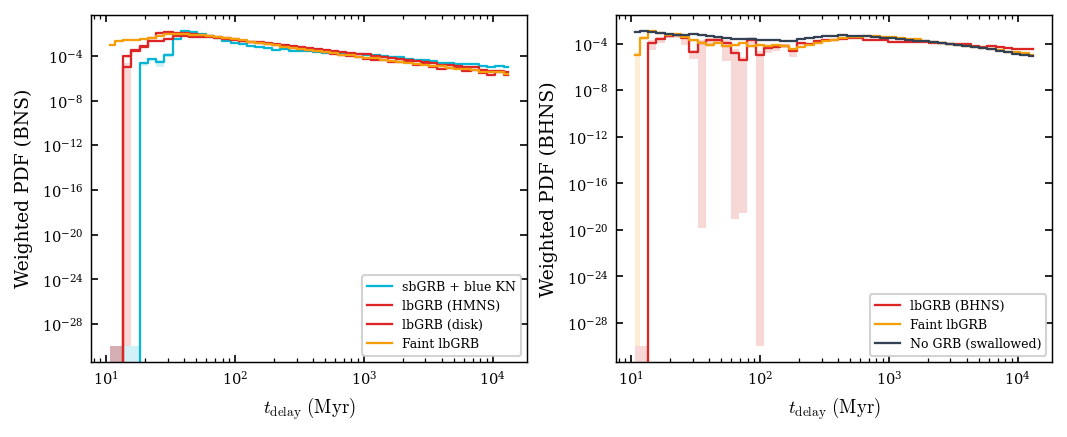

In [16]:
bins_delay = np.logspace(np.log10(10), np.log10(14000), 50)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.8),
                               constrained_layout=True)

for lbl, mask, c in bns_classes:
    h = _weighted_hist_pdf(delay_bns, mask, w_bns, bins_delay)
    if h is None:
        continue
    x, mu, sig = h
    ax1.fill_between(x, np.maximum(mu - sig, 1e-30), mu + sig, color=c,
                     alpha=0.18, step='mid', linewidth=0)
    ax1.step(x, mu, where='mid', color=c, lw=1.1, label=lbl)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
ax1.set_ylabel('Weighted PDF (BNS)')
ax1.legend(fontsize=6, loc='lower right', framealpha=0.85)

for lbl, mask, c in bhns_classes:
    h = _weighted_hist_pdf(delay_bhns, mask, w_bhns, bins_delay)
    if h is None:
        continue
    x, mu, sig = h
    ax2.fill_between(x, np.maximum(mu - sig, 1e-30), mu + sig, color=c,
                     alpha=0.18, step='mid', linewidth=0)
    ax2.step(x, mu, where='mid', color=c, lw=1.1, label=lbl)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
ax2.set_ylabel('Weighted PDF (BHNS)')
ax2.legend(fontsize=6, loc='lower right', framealpha=0.85)

fig.savefig('Plots/delay_time_distributions.png', dpi=300)
fig.savefig('Plots/delay_time_distributions.pdf')
plt.show()


## 4. Cosmic Integration: MSSFR Grid Setup

Pure plumbing for Sections 5, 7, 8, 12: Madau and Dickinson (2014) SFR convolved with the Neijssel et al. (2019) log-normal metallicity PDF via the COMPAS `FastCosmicIntegration` library, then per-population calibration of $M_\mathrm{evolved}$. `dPdlogZ` is per $d(\ln Z)$, not $d(\log_{10} Z)$ (`check_dPdlogZ_normalization`).

In [17]:
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'COMPAS'))
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params, find_sfr, find_metallicity_distribution)

# CLAUDE.md mandate: Planck 2015 (H0 = 67.74, Om = 0.3089, OmL = 0.6911) to
# match COMPAS FastCosmicIntegration TNG-consistent values.  COMPAS
# cosmology.py defaults to Planck18, so we pass Planck15 explicitly to every
# call; otherwise distances and shell volumes drift by ~2 percent at high z.
from astropy.cosmology import Planck15 as PLANCK15
assert abs(PLANCK15.H0.value - 67.74) < 0.01

redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01,
                                       cosmology=PLANCK15)
sfr = find_sfr(redshifts)

Z_range_bns = verify_shared_metallicity_prior(DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(Z_range_bns[0]),
    max_logZ_COMPAS=np.log(Z_range_bns[1]))

# Verify dP/dlnZ integrates to ~1 at every redshift slice (Neijssel+ 2019).
try:
    dPdlogZ_norm = check_dPdlogZ_normalization(dPdlogZ, metallicities, rtol=0.10)
except ValueError:
    dlogZ = np.diff(np.log(metallicities))
    dlogZ = np.append(dlogZ, dlogZ[-1])
    dPdlogZ = dPdlogZ / (dPdlogZ * dlogZ[None, :]).sum(axis=1)[:, None]
    dPdlogZ_norm = (dPdlogZ * dlogZ[None, :]).sum(axis=1)

# Per-population calibration. Pin Z_grid to the simulation's full grid so
# every per-class subset uses identical Voronoi cells.
expected_rate_bns  = read_expected_local_rate(DEFAULT_BNS_PATH)
expected_rate_bhns = read_expected_local_rate(DEFAULT_BHNS_PATH)
Z_grid_BNS  = np.unique(Z_bns)
Z_grid_BHNS = np.unique(Z_bhns)

mean_mass_bns, _  = calibrate_mean_mass_evolved(
    sfr, redshifts, times, time_first_SF, p_draw,
    Z_bns, delay_bns, w_bns, expected_rate_bns,
    Z_grid=Z_grid_BNS)
mean_mass_bhns, _ = calibrate_mean_mass_evolved(
    sfr, redshifts, times, time_first_SF, p_draw,
    Z_bhns, delay_bhns, w_bhns, expected_rate_bhns,
    Z_grid=Z_grid_BHNS)
n_formed_BNS  = sfr / mean_mass_bns
n_formed_BHNS = sfr / mean_mass_bhns

print(f"SFR(z=0)            = {sfr[0]:.3e} Msun/yr/Gpc^3 (M&D 2014: ~1e7)")
print(f"dPdlogZ integral    in [{dPdlogZ_norm.min():.3f}, {dPdlogZ_norm.max():.3f}]")
print(f"p_draw              = {p_draw:.6f}")
print(f"BNS  R_loc expected = {expected_rate_bns:6.1f} Gpc^-3 yr^-1, "
      f"M_evolved = {mean_mass_bns:.3e} Msun")
print(f"BHNS R_loc expected = {expected_rate_bhns:6.1f} Gpc^-3 yr^-1, "
      f"M_evolved = {mean_mass_bhns:.3e} Msun")


SFR(z=0)            = 9.933e+06 Msun/yr/Gpc^3 (M&D 2014: ~1e7)
dPdlogZ integral    in [1.000, 1.000]
p_draw              = 0.175322
BNS  R_loc expected =   33.4 Gpc^-3 yr^-1, M_evolved = 5.371e+08 Msun
BHNS R_loc expected =   43.0 Gpc^-3 yr^-1, M_evolved = 7.498e+08 Msun


## 5. Metallicity Dependence of GRB Formation Efficiency

Formation efficiency $\eta(Z)$ (mergers per $M_\odot$ formed) per Gottlieb (2024) class. Lower-$Z$ stars produce heavier remnants and shift the class balance with $Z$ (and so with $z$ via the MSSFR convolution). $Z_\odot = 0.0142$ (Asplund et al. 2009); bins with fewer than $N_\mathrm{min}$ simulated systems are faded.

BNS  : 53/53 bins well-sampled (N >= 50); coverage Z/Zsun [0.007, 2.113]
BHNS : 49/53 bins well-sampled


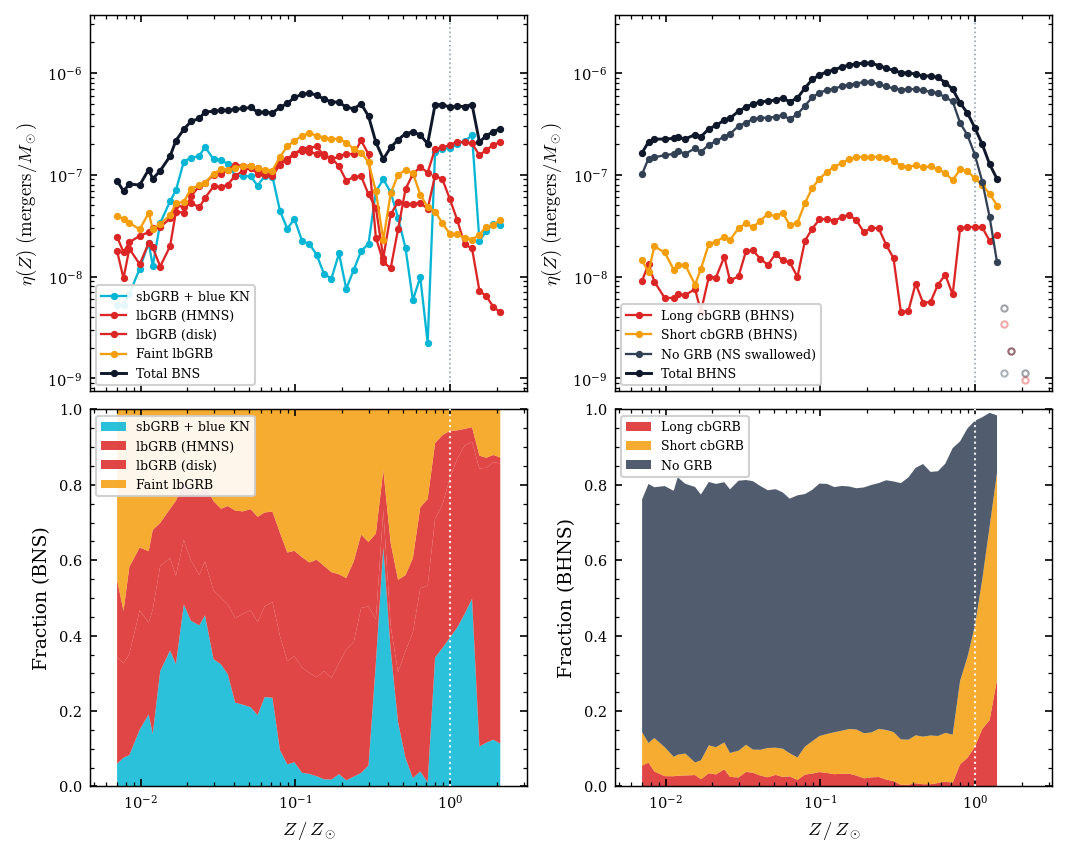

In [18]:
eff_bns = formation_efficiency(
    METALLICITY_GRID, Z_bns, w_bns,
    masks={'sbGRB + blue KN': sbGRB_blue,
           'lbGRB (HMNS)':    lbGRB_hmns,
           'lbGRB (disk)':    lbGRB_disk,
           'Faint lbGRB':     bns_faint_lb},
    mean_mass_evolved=mean_mass_bns)
eff_bhns = formation_efficiency(
    METALLICITY_GRID, Z_bhns, w_bhns,
    masks={'Long cbGRB (BHNS)':     bhns_long,
           'Short cbGRB (BHNS)':    bhns_faint_lb,
           'No GRB (NS swallowed)': bhns_no_grb},
    mean_mass_evolved=mean_mass_bhns)

# Drop the duplicated final 0.03 entry in METALLICITY_GRID.
Z_SUN = 0.0142
_uniq_mask = np.concatenate(([True], np.diff(METALLICITY_GRID) != 0))
Z_grid = METALLICITY_GRID[_uniq_mask]
Z_over_Zsun = Z_grid / Z_SUN

# Vectorized per-bin sample counts via searchsorted + bincount; no Python
# loop over the metallicity grid.
def _bin_counts(Z_systems, grid):
    idx = np.clip(np.searchsorted(grid, Z_systems), 0, len(grid) - 1)
    return np.bincount(idx, minlength=len(grid))

N_bns  = _bin_counts(Z_bns,  Z_grid)
N_bhns = _bin_counts(Z_bhns, Z_grid)
N_MIN  = 50
ok_bns_bin  = N_bns  >= N_MIN
ok_bhns_bin = N_bhns >= N_MIN

print(f'BNS  : {ok_bns_bin.sum():>2d}/{len(Z_grid)} bins well-sampled '
      f'(N >= {N_MIN}); coverage Z/Zsun '
      f'[{Z_over_Zsun[ok_bns_bin].min():.3f}, '
      f'{Z_over_Zsun[ok_bns_bin].max():.3f}]')
print(f'BHNS : {ok_bhns_bin.sum():>2d}/{len(Z_grid)} bins well-sampled')

def _split(arr, ok_bin):
    a = arr[_uniq_mask].astype(float)
    a[a <= 0] = np.nan
    return (np.where(ok_bin, a, np.nan),
            np.where(~ok_bin & np.isfinite(a), a, np.nan))

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6), sharex=True,
                         constrained_layout=True)

def _draw_efficiency(ax, eff, classes, ok_bin, total_label):
    for lbl, c in classes:
        well, under = _split(eff[lbl], ok_bin)
        ax.plot(Z_over_Zsun, well,  color=c, lw=1.1, marker='o', ms=2.5,
                label=lbl)
        ax.plot(Z_over_Zsun, under, color=c, lw=0, marker='o', mfc='none',
                ms=3, alpha=0.4)
    well_t, under_t = _split(eff['total'], ok_bin)
    ax.plot(Z_over_Zsun, well_t,  color=C_TEXT, lw=1.4, marker='o', ms=2.5,
            label=total_label)
    ax.plot(Z_over_Zsun, under_t, color=C_TEXT, lw=0, marker='o', mfc='none',
            ms=3, alpha=0.4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(1.0, color=C_GUIDE, lw=0.8, ls=':', zorder=0)
    ax.set_ylabel(r'$\eta(Z)\ (\mathrm{mergers}/M_\odot)$')

_draw_efficiency(axes[0, 0], eff_bns,
                 [('sbGRB + blue KN', C_SB_BLUE),
                  ('lbGRB (HMNS)',    C_LB_HMNS),
                  ('lbGRB (disk)',    C_LB_DISK),
                  ('Faint lbGRB',     C_FAINT)],
                 ok_bns_bin, 'Total BNS')
axes[0, 0].legend(fontsize=6, loc='lower left', framealpha=0.9)

_draw_efficiency(axes[0, 1], eff_bhns,
                 [('Long cbGRB (BHNS)',     C_LONG_BH),
                  ('Short cbGRB (BHNS)',    C_FAINT_BH),
                  ('No GRB (NS swallowed)', C_NO_GRB)],
                 ok_bhns_bin, 'Total BHNS')
axes[0, 1].legend(fontsize=6, loc='lower left', framealpha=0.9)

# Lock y-range to well-sampled bins so a single under-sampled outlier
# doesn't drag the floor down.
def _well_sampled_range(eff, ok_bin):
    vals = []
    for v in eff.values():
        a = v[_uniq_mask][ok_bin]
        a = a[a > 0]
        if a.size:
            vals.append(a)
    return (np.concatenate(vals).min(), np.concatenate(vals).max()) if vals else None

ranges = [r for r in (_well_sampled_range(eff_bns,  ok_bns_bin),
                      _well_sampled_range(eff_bhns, ok_bhns_bin)) if r]
if ranges:
    axes[0, 0].set_ylim(min(r[0] for r in ranges) / 3.0,
                        max(r[1] for r in ranges) * 3.0)
    axes[0, 1].set_ylim(*axes[0, 0].get_ylim())

# Fraction stackplots.
def _stack(ax, eff, ok_bin, keys, colors, labels, ylabel):
    denom = eff['total'][_uniq_mask]
    sel   = ok_bin & (denom > 0)
    with np.errstate(invalid='ignore', divide='ignore'):
        fracs = np.stack([eff[k][_uniq_mask] / denom for k in keys])
    ax.stackplot(Z_over_Zsun[sel], *fracs[:, sel],
                 colors=colors, labels=labels, alpha=0.85)
    ax.set_xscale('log')
    ax.set_xlabel(r'$Z\,/\,Z_\odot$')
    ax.set_ylabel(ylabel)
    ax.axvline(1.0, color='white', lw=1.0, ls=':', alpha=0.9, zorder=5)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=6, loc='upper left', framealpha=0.9)

_stack(axes[1, 0], eff_bns, ok_bns_bin,
       ['sbGRB + blue KN', 'lbGRB (HMNS)', 'lbGRB (disk)', 'Faint lbGRB'],
       [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT],
       ['sbGRB + blue KN', 'lbGRB (HMNS)', 'lbGRB (disk)', 'Faint lbGRB'],
       'Fraction (BNS)')
_stack(axes[1, 1], eff_bhns, ok_bhns_bin,
       ['Long cbGRB (BHNS)', 'Short cbGRB (BHNS)', 'No GRB (NS swallowed)'],
       [C_LONG_BH, C_FAINT_BH, C_NO_GRB],
       ['Long cbGRB', 'Short cbGRB', 'No GRB'],
       'Fraction (BHNS)')

# Lock x-range to well-sampled coverage.
xs = [Z_over_Zsun[ok] for ok in (ok_bns_bin, ok_bhns_bin) if ok.any()]
if xs:
    cat = np.concatenate(xs)
    for a in axes.flat:
        a.set_xlim(cat.min() / 1.5, cat.max() * 1.5)

fig.savefig('Plots/metallicity_dependence.png', dpi=300)
fig.savefig('Plots/metallicity_dependence.pdf')
plt.show()


## 6. Formation Channel Breakdown per GRB Class

BNS formation-channel decomposition (Broekgaarden et al. 2021, 2022): I (Classic CE), II (Stable MT only), III (Single-core CE), IV (Double-core CE), V (Other). Bars are STROOPWAFEL-weighted percentages of each Gottlieb (2024) GRB class.

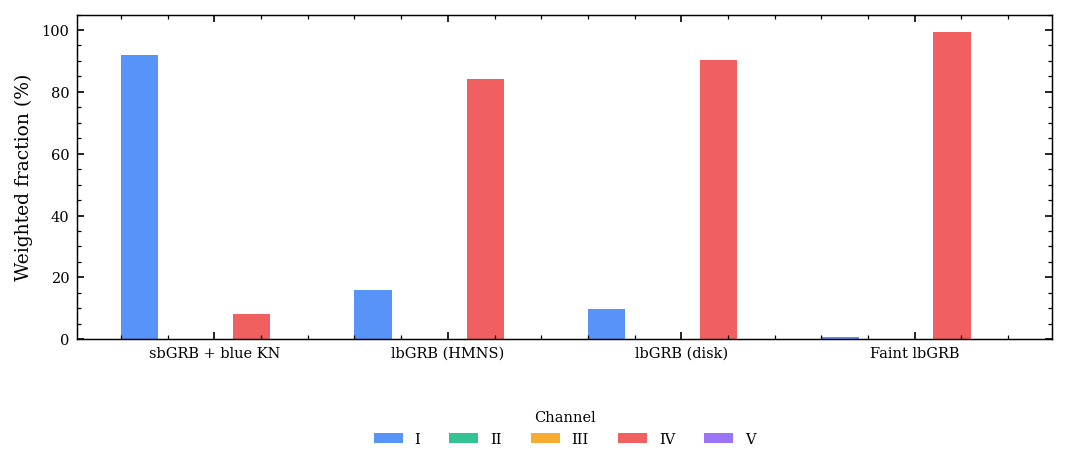

In [19]:
channels = classify_formation_channels(
    dblCE=bns_ch['dblCE'], fc_CEE=bns_ch['fc_CEE'],
    fc_mt_p1=bns_ch['fc_mt_p1'], fc_mt_s1=bns_ch['fc_mt_s1'],
    fc_mt_p1_K1=bns_ch['fc_mt_p1_K1'], fc_mt_s1_K2=bns_ch['fc_mt_s1_K2'])

ch_keys     = list(channels.keys())
ch_short    = ['I', 'II', 'III', 'IV', 'V'][:len(ch_keys)]
class_keys  = ['sbGRB + blue KN', 'lbGRB (HMNS)', 'lbGRB (disk)', 'Faint lbGRB']
class_masks = [sbGRB_blue, lbGRB_hmns, lbGRB_disk, bns_faint_lb]

# Single (n_channel, n_class) weighted-fraction matrix; broadcasting over
# ~10^6 systems replaces the original double Python loop.
ch_arr   = np.stack([channels[k] for k in ch_keys])                 # (5, N)
cls_arr  = np.stack(class_masks)                                    # (4, N)
joint_w  = ((ch_arr[:, None, :] & cls_arr[None, :, :]) * w_bns).sum(-1)
denom    = (cls_arr * w_bns).sum(-1)                                # (4,)
fracs    = 100.0 * joint_w / denom                                  # (5, 4)

ch_colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']
fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
x       = np.arange(len(class_keys))
width   = 0.16
offsets = (np.arange(len(ch_keys)) - (len(ch_keys) - 1) / 2.0) * width
for j, (label, color) in enumerate(zip(ch_short, ch_colors)):
    ax.bar(x + offsets[j], fracs[j], width, label=label, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_keys)
ax.set_ylabel('Weighted fraction (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=7, ncol=len(ch_keys), loc='upper center',
          bbox_to_anchor=(0.5, -0.18), title='Channel', title_fontsize=7,
          frameon=False)

fig.savefig('Plots/formation_channels_by_grb_class.png', dpi=300)
fig.savefig('Plots/formation_channels_by_grb_class.pdf')
plt.show()


## 7. BNS Merger Rate $\mathcal{R}(z)$ per GRB Class

Intrinsic comoving merger-rate density (Gpc$^{-3}$ yr$^{-1}$) per Gottlieb (2024) class, from Madau and Dickinson (2014) SFR convolved with Neijssel et al. (2019) $dP/d\ln Z$ and the per-system delay times under Planck 2015. Rates are intrinsic and assume 100 percent jet launching above threshold; they are upper bounds. Shaded bands are weighted-Poisson $1\sigma$ intervals from `per_system_rate_weights`, $\sigma_R(z) = \sqrt{\sum_i w_i^2(z)}$. The bimodal `sbGRB + blue KN` curve at $z \gtrsim 4$ reflects the low-$Z$ formation-channel dominance for the lightest BNS systems ($M_\mathrm{tot} < 1.2\,M_\mathrm{TOV}$) in Broekgaarden et al. (2021) Model A, not a numerical artifact: the per-class rates sum to the all-BNS curve at machine precision (regression-tested in `tests/test_rates.py::test_per_class_rates_partition_total_bns_2024`).

  sbGRB + blue KN     R(z=0) =       11 +/- 0.17 Gpc^-3 yr^-1
  lbGRB (HMNS)        R(z=0) =       17 +/- 0.077 Gpc^-3 yr^-1
  lbGRB (disk)        R(z=0) =        2 +/- 0.065 Gpc^-3 yr^-1
  Faint lbGRB         R(z=0) =        3 +/- 0.051 Gpc^-3 yr^-1
  All BNS             R(z=0) =       33 +/- 0.21 Gpc^-3 yr^-1


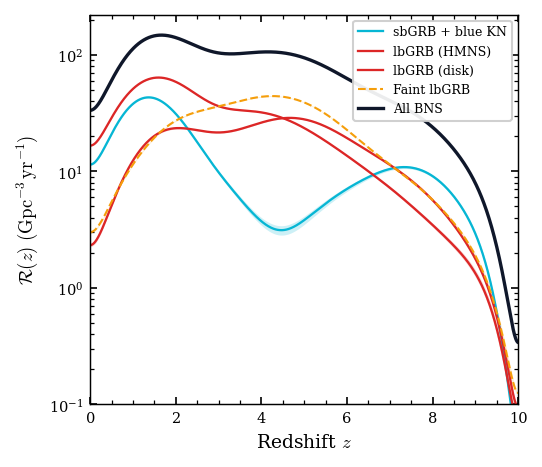

In [20]:
from grb_rates import per_system_rate_weights

classes_BNS_24 = [
    ('sbGRB + blue KN', sbGRB_blue),
    ('lbGRB (HMNS)',    lbGRB_hmns),
    ('lbGRB (disk)',    lbGRB_disk),
    ('Faint lbGRB',     bns_faint_lb),
    ('All BNS',         np.ones(len(delay_bns), dtype=bool)),
]

merger_rates_BNS = {}
for label, mask in classes_BNS_24:
    merger_rates_BNS[label] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, p_draw,
        Z_bns[mask], delay_bns[mask], w_bns[mask],
        Z_grid=Z_grid_BNS)

# Per-class weighted-Poisson 1 sigma envelope: sigma_R(z) = sqrt(sum_i w_i^2),
# where w_i is the per-system rate contribution from per_system_rate_weights
# at z_target.  Evaluated on a coarse z grid then interpolated to redshifts;
# at smooth_sigma=0 the per_system kernel equals the integrand of
# compute_merger_rate so the central value tracks the existing R(z) curve.
z_band = np.linspace(0.0, redshifts.max(), 21)
sigma_per_class = {}
for label, mask in classes_BNS_24:
    sig = np.zeros_like(z_band)
    for j, z in enumerate(z_band):
        wi = per_system_rate_weights(
            z, redshifts, times, time_first_SF, n_formed_BNS, p_draw,
            Z_bns[mask], delay_bns[mask], w_bns[mask], Z_grid=Z_grid_BNS)
        sig[j] = float(np.sqrt(np.sum(wi ** 2)))
    sigma_per_class[label] = np.interp(redshifts, z_band, sig)

iz0 = np.argmin(np.abs(redshifts))
for label in [c[0] for c in classes_BNS_24]:
    print(f"  {label:18s}  R(z=0) = {rate_label(merger_rates_BNS[label][iz0]):>8s} "
          f"+/- {sigma_per_class[label][iz0]:.2g} Gpc^-3 yr^-1")

fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
style = [('sbGRB + blue KN', C_SB_BLUE,  '-',  1.1),
         ('lbGRB (HMNS)',    C_LB_HMNS,  '-',  1.1),
         ('lbGRB (disk)',    C_LB_DISK,  '-',  1.1),
         ('Faint lbGRB',     C_FAINT,    '--', 1.0),
         ('All BNS',         C_TEXT,     '-',  1.6)]
for lbl, c, ls, lw in style:
    R = merger_rates_BNS[lbl]
    sig = sigma_per_class[lbl]
    ax.fill_between(redshifts, np.maximum(R - sig, 1e-30), R + sig,
                    color=c, alpha=0.20, lw=0)
    ax.plot(redshifts, R, color=c, ls=ls, lw=lw, label=lbl)
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right')
fig.savefig('Plots/rate_bns_by_class.png', dpi=300)
fig.savefig('Plots/rate_bns_by_class.pdf')
plt.show()


## 8. BHNS Merger Rate $\mathcal{R}(z)$ with BH Spin Sensitivity

BHNS rates depend strongly on $a_\mathrm{BH}$: higher spins push the ISCO inward, raising the surviving NS fraction (Foucart 2018). The lighter envelope brackets the BH-spin systematic $a = 0$-$0.9$ (Foucart calibration $\chi_\mathrm{BH} \in [-0.5, 0.9]$, enforced via `clip_chi=0.9`). The darker tighter band along the central line is the weighted-Poisson $1\sigma$ statistical uncertainty at the fiducial $a_\mathrm{BH} = 0.5$, computed via `per_system_rate_weights` for direct parity with the Section 7 BNS panel. The hatched band shows the population-averaged spin-orbit misalignment correction (`apply_bhns_misalignment`, factor 0.5; Fragos et al. 2010, Kawaguchi et al. 2015).

/Users/josephrodriguez/research visualization/grb_physics.py:661: UserWarning: Foucart (2018) formula applied to 410646 systems with Q > 7 (max Q=29.0); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(M_BH, M_NS, a_BH=a_BH,


  a=0.0  Long:   0.00  Short:      2 Gpc^-3 yr^-1
  a=0.3  Long:   0.00  Short:      6 Gpc^-3 yr^-1
  a=0.5  Long:      2  Short:      9 Gpc^-3 yr^-1
  a=0.7  Long:      8  Short:     14 Gpc^-3 yr^-1
  a=0.9  Long:     27  Short:      8 Gpc^-3 yr^-1


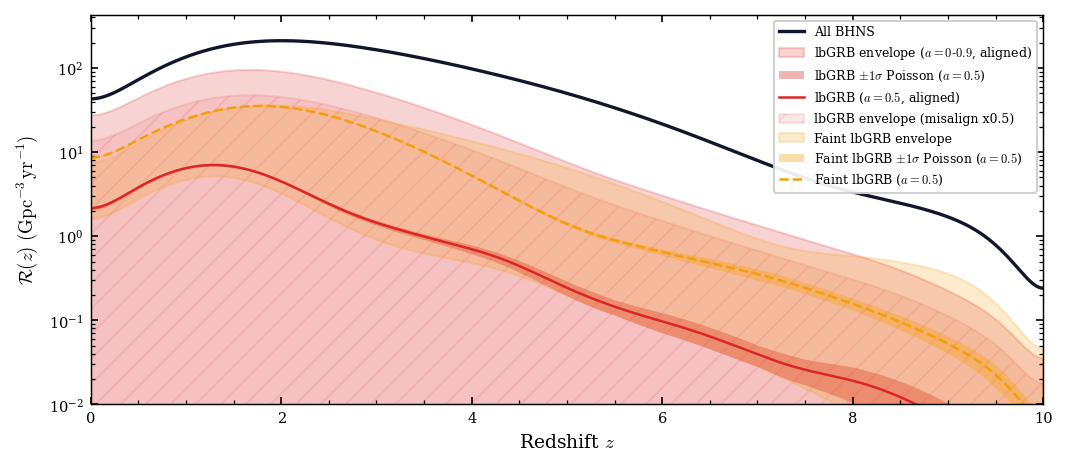

In [21]:
spin_grid = [0.0, 0.3, 0.5, 0.7, 0.9]
spin_rates_long, spin_rates_short = {}, {}
for a in spin_grid:
    cbh = classify_bhns(BH, NS_bh, a_BH=a, clip_chi=0.9)
    spin_rates_long[a]  = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        Z_bhns[cbh['Long cbGRB']],  delay_bhns[cbh['Long cbGRB']],
        w_bhns[cbh['Long cbGRB']],  Z_grid=Z_grid_BHNS)
    spin_rates_short[a] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        Z_bhns[cbh['Short cbGRB']], delay_bhns[cbh['Short cbGRB']],
        w_bhns[cbh['Short cbGRB']], Z_grid=Z_grid_BHNS)

iz0 = np.argmin(np.abs(redshifts))
for a in spin_grid:
    print(f"  a={a:.1f}  Long: {rate_label(spin_rates_long[a][iz0]):>6s}  "
          f"Short: {rate_label(spin_rates_short[a][iz0]):>6s} Gpc^-3 yr^-1")

# BH-spin marginalization (moved from the dropped Section 11). Flat prior is
# uniform over the spin grid; Fuller and Ma (2019, arXiv:1905.08793) predict
# efficient angular-momentum transport, so most BHs form with low spin.
w_flat = {0.0: 0.20, 0.3: 0.20, 0.5: 0.20, 0.7: 0.20, 0.9: 0.20}
w_fm19 = {0.0: 0.70, 0.3: 0.20, 0.5: 0.07, 0.7: 0.02, 0.9: 0.01}
r_long_flat  = marginalize_bh_spin(spin_rates_long,  w_flat)
r_long_fm19  = marginalize_bh_spin(spin_rates_long,  w_fm19)
r_short_flat = marginalize_bh_spin(spin_rates_short, w_flat)
r_short_fm19 = marginalize_bh_spin(spin_rates_short, w_fm19)

rate_bhns_all = compute_merger_rate(
    redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
    Z_bhns, delay_bhns, w_bhns, Z_grid=Z_grid_BHNS)

# Per-class weighted-Poisson 1 sigma envelope at the fiducial a_BH = 0.5,
# matching the Section 7 BNS treatment so both rate panels carry the same
# statistical uncertainty representation (CLAUDE.md "uncertainty is not
# optional").  The narrower Poisson shading sits inside the wider BH-spin
# systematic envelope and reads as a separate darker "tube".
cbh_fid = classify_bhns(BH, NS_bh, a_BH=A_BH_FID, clip_chi=0.9)
z_band_bhns = np.linspace(0.0, redshifts.max(), 21)


def _poisson_sigma(mask):
    if not mask.any():
        return np.zeros_like(redshifts)
    sig = np.zeros_like(z_band_bhns)
    for j, z in enumerate(z_band_bhns):
        wi = per_system_rate_weights(
            z, redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
            Z_bhns[mask], delay_bhns[mask], w_bhns[mask], Z_grid=Z_grid_BHNS)
        sig[j] = float(np.sqrt(np.sum(wi ** 2)))
    return np.interp(redshifts, z_band_bhns, sig)


sigma_long_fid  = _poisson_sigma(cbh_fid['Long cbGRB'])
sigma_short_fid = _poisson_sigma(cbh_fid['Short cbGRB'])

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
ax.plot(redshifts, rate_bhns_all, color=C_TEXT, lw=1.6, label='All BHNS')
ax.fill_between(redshifts, spin_rates_long[0.0], spin_rates_long[0.9],
                color=C_LONG_BH, alpha=0.20,
                label=r'lbGRB envelope ($a=0$-$0.9$, aligned)')
ax.fill_between(redshifts,
                np.maximum(spin_rates_long[0.5] - sigma_long_fid, 1e-30),
                spin_rates_long[0.5] + sigma_long_fid,
                color=C_LONG_BH, alpha=0.35, lw=0,
                label=r'lbGRB $\pm 1\sigma$ Poisson ($a=0.5$)')
ax.plot(redshifts, spin_rates_long[0.5], color=C_LONG_BH, lw=1.2,
        label=r'lbGRB ($a=0.5$, aligned)')
ax.fill_between(redshifts,
                apply_bhns_misalignment(spin_rates_long[0.0]),
                apply_bhns_misalignment(spin_rates_long[0.9]),
                color=C_LONG_BH, alpha=0.10, hatch='//',
                label=rf'lbGRB envelope (misalign x{MISALIGNMENT_SYSTEMATIC_FACTOR})')
ax.fill_between(redshifts, spin_rates_short[0.0], spin_rates_short[0.9],
                color=C_FAINT_BH, alpha=0.20, label='Faint lbGRB envelope')
ax.fill_between(redshifts,
                np.maximum(spin_rates_short[0.5] - sigma_short_fid, 1e-30),
                spin_rates_short[0.5] + sigma_short_fid,
                color=C_FAINT_BH, alpha=0.35, lw=0,
                label=r'Faint lbGRB $\pm 1\sigma$ Poisson ($a=0.5$)')
ax.plot(redshifts, spin_rates_short[0.5], color=C_FAINT_BH, lw=1.2, ls='--',
        label=r'Faint lbGRB ($a=0.5$)')
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.01)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right')
fig.savefig('Plots/rate_bhns_spin_sensitivity.png', dpi=300)
fig.savefig('Plots/rate_bhns_spin_sensitivity.pdf')
plt.show()


## 9. Physical Host-Galaxy Offset Distributions

Orbit-integrated projected offsets in a Hernquist (1990) potential, replacing the unbound ballistic upper bound (Bloom et al. 1999, Fong and Berger 2013). Each binary's birth radius is drawn from the Hernquist stellar profile; kicks are isotropic. Hosts are a 75/25 mix of star-forming and elliptical (Fong and Berger 2013); the F&B sample is afterglow + host selected, so model CDFs extend to larger offsets than the observed sample.

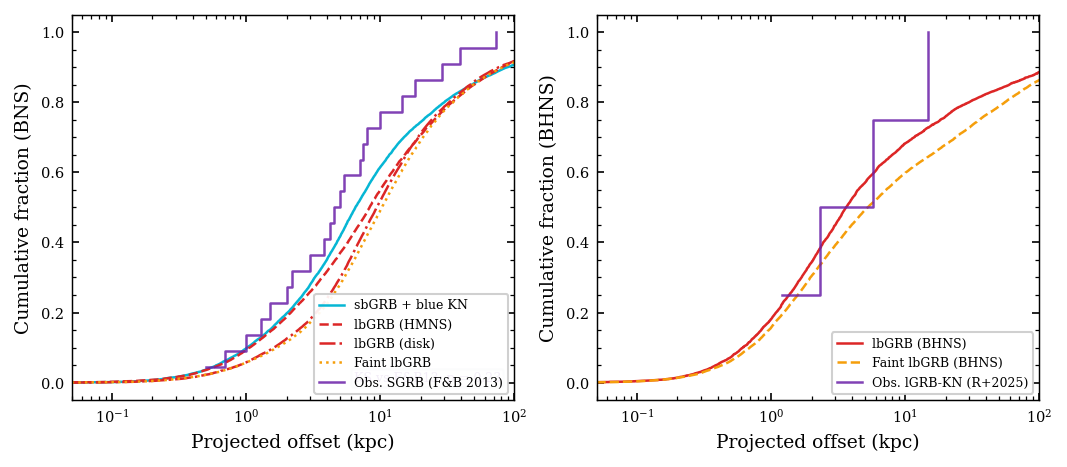

In [22]:
from grb_offsets import (compute_offsets_mixed_hosts,
                         weighted_offset_cdf,
                         OBSERVED_SGRB_OFFSETS_KPC,
                         OBSERVED_LGRB_MERGER_OFFSETS_KPC)
from scipy.stats import ks_2samp

bns_classes_off = [
    ('sbGRB + blue KN', sbGRB_blue,   C_SB_BLUE, '-'),
    ('lbGRB (HMNS)',    lbGRB_hmns,   C_LB_HMNS, '--'),
    ('lbGRB (disk)',    lbGRB_disk,   C_LB_DISK, '-.'),
    ('Faint lbGRB',     bns_faint_lb, C_FAINT,   ':'),
]
bhns_classes_off = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH,  '-'),
    ('Faint lbGRB (BHNS)', bhns_faint_lb, C_FAINT_BH, '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

ax1 = axes[0]
bns_offset_results = {}
ks_results_bns = {}
for lbl, mask, c, ls in bns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bns[mask], delay_bns[mask], weights=w_bns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    bns_offset_results[lbl] = (res['mixed_offsets'], res['mixed_weights'])
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax1.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
    finite = res['mixed_offsets'][np.isfinite(res['mixed_offsets'])]
    if len(finite) > 1:
        ks_results_bns[lbl] = ks_2samp(finite, OBSERVED_SGRB_OFFSETS_KPC)

obs_sorted = np.sort(OBSERVED_SGRB_OFFSETS_KPC)
obs_cdf    = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
ax1.step(obs_sorted, obs_cdf, color=C_OBS, lw=1.2, ls='-', alpha=0.85,
         where='post', label='Obs. SGRB (F&B 2013)')
if 'lbGRB (HMNS)' in ks_results_bns:
    ks = ks_results_bns['lbGRB (HMNS)']
    ax1.text(0.97, 0.04, f'KS vs F&B13: p = {ks.pvalue:.2g}',
             transform=ax1.transAxes, fontsize=6, ha='right', va='bottom',
             color=C_OBS,
             bbox=dict(boxstyle='round,pad=0.2', fc='white',
                       ec=C_BOX_EDGE, alpha=0.85))
ax1.set_xscale('log')
ax1.set_xlim(0.05, 100)
ax1.set_xlabel(r'Projected offset (kpc)')
ax1.set_ylabel(r'Cumulative fraction (BNS)')
ax1.legend(fontsize=6, loc='lower right')

ax2 = axes[1]
for lbl, mask, c, ls in bhns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bhns[mask], delay_bhns[mask], weights=w_bhns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax2.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
if len(OBSERVED_LGRB_MERGER_OFFSETS_KPC) > 0:
    obs_l_sorted = np.sort(OBSERVED_LGRB_MERGER_OFFSETS_KPC)
    obs_l_cdf    = np.arange(1, len(obs_l_sorted) + 1) / len(obs_l_sorted)
    ax2.step(obs_l_sorted, obs_l_cdf, color=C_OBS, lw=1.2, ls='-',
             alpha=0.85, where='post', label='Obs. lGRB-KN (R+2025)')
ax2.set_xscale('log')
ax2.set_xlim(0.05, 100)
ax2.set_xlabel(r'Projected offset (kpc)')
ax2.set_ylabel(r'Cumulative fraction (BHNS)')
ax2.legend(fontsize=6, loc='lower right')

fig.savefig('Plots/projected_offsets.png', dpi=300)
fig.savefig('Plots/projected_offsets.pdf')
plt.show()


## 10. Beaming Correction: Intrinsic vs Observable GRB Rates

GRB detectors see only jets within $\theta_j$ of the line of sight, so $\mathcal{R}_\mathrm{obs} = (1 - \cos\theta_j) \mathcal{R}_\mathrm{intrinsic}$. We use class-dependent $\theta_j$ from `CLASS_THETA_J` (sbGRB: Fong+ 2015, Beniamini and Nakar 2019; lbGRB: Gottlieb 2023). The Wanderman and Piran (2015, MNRAS 448, 3026) reference curve uses their Eq. (9) piecewise exponential in $z - z_\mathrm{peak}$ ($z_\mathrm{peak} = 0.9$, $\sigma_\mathrm{lo} = 0.39$, $\sigma_\mathrm{hi} = 0.26$, $R_0 = 4.1^{+2.3}_{-1.9}$ Gpc$^{-3}$ yr$^{-1}$).

Class                         R_int  theta_j  R_obs(fid)   R_obs(lo)   R_obs(hi)
BNS sbGRB + blue KN              11       13        0.29        0.17        0.44
BNS lbGRB (HMNS)                 17        6        0.11        0.06        0.16
BNS lbGRB (disk)                  2        6        0.01        0.01        0.02
BNS All                          33       13        0.86        0.51        1.29
BHNS lbGRB (F&M)               0.58        6        0.00        0.00        0.01
Observed sGRB references:
  Wanderman & Piran 2015: 4.1 (2.2-6.4) Gpc^-3 yr^-1
  Ghirlanda+ 2016: 1.3 (0.5-3.0) Gpc^-3 yr^-1
  Colombo+ 2022: 3.6 (1.8-6.5) Gpc^-3 yr^-1


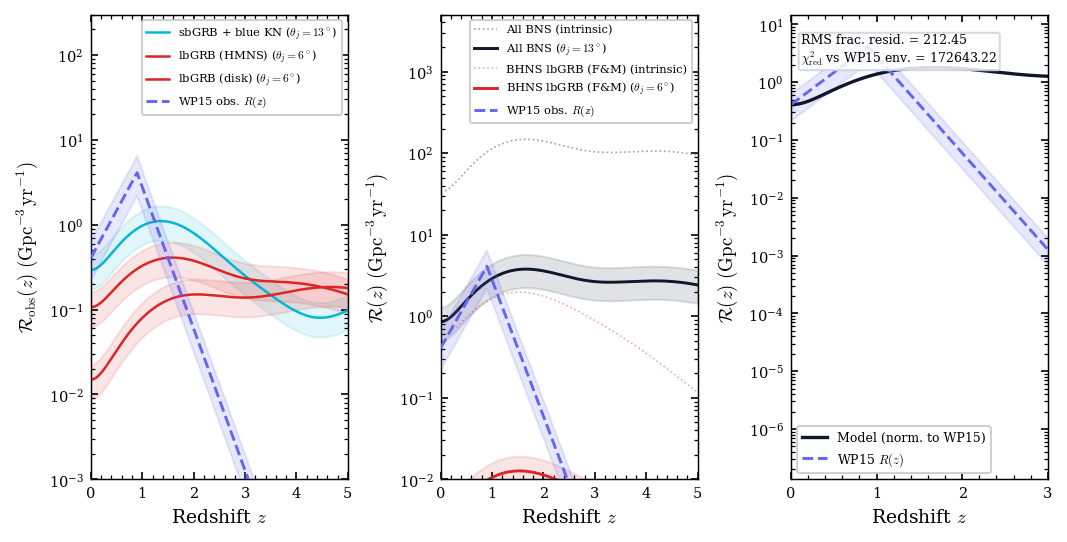

In [23]:
iz0 = np.argmin(np.abs(redshifts))
theta_sb = CLASS_THETA_J['sbGRB']
theta_lb = CLASS_THETA_J['lbGRB']

beaming_rows = [
    ('BNS sbGRB + blue KN',  merger_rates_BNS['sbGRB + blue KN'][iz0], theta_sb),
    ('BNS lbGRB (HMNS)',     merger_rates_BNS['lbGRB (HMNS)'][iz0],    theta_lb),
    ('BNS lbGRB (disk)',     merger_rates_BNS['lbGRB (disk)'][iz0],    theta_lb),
    ('BNS All',              merger_rates_BNS['All BNS'][iz0],         theta_sb),
    ('BHNS lbGRB (F&M)',     r_long_fm19[iz0],                         theta_lb),
]
print(f"{'Class':<24s} {'R_int':>10s} {'theta_j':>8s} "
      f"{'R_obs(fid)':>11s} {'R_obs(lo)':>11s} {'R_obs(hi)':>11s}")
for lbl, r_int, th in beaming_rows:
    print(f"{lbl:<24s} {rate_label(r_int):>10s} {th['fid']:>8.0f} "
          f"{beamed_rate(r_int, th['fid']):>11.2f} "
          f"{beamed_rate(r_int, th['lo']):>11.2f} "
          f"{beamed_rate(r_int, th['hi']):>11.2f}")
print('Observed sGRB references:')
for ref, d in OBSERVED_SGRB_RATES.items():
    print(f"  {ref}: {d['R_obs']:.1f} ({d['R_obs_lo']:.1f}-{d['R_obs_hi']:.1f}) Gpc^-3 yr^-1")

z_mask  = redshifts <= 5.0
z_plot  = redshifts[z_mask]
wp15_Rz = wanderman_piran_2015_Rz(z_plot)

fig, axes = plt.subplots(1, 3, figsize=(7.0, 3.5), constrained_layout=True)

ax1 = axes[0]
for lbl, c, th in [('sbGRB + blue KN', C_SB_BLUE, theta_sb),
                    ('lbGRB (HMNS)',    C_LB_HMNS, theta_lb),
                    ('lbGRB (disk)',    C_LB_DISK, theta_lb)]:
    r_z   = merger_rates_BNS[lbl]
    r_fid = beamed_rate(r_z, th['fid'])
    ax1.plot(z_plot, r_fid[z_mask], color=c, lw=1.2,
             label=rf'{lbl} ($\theta_j={th["fid"]:.0f}^\circ$)')
    ax1.fill_between(z_plot,
                     beamed_rate(r_z, th['lo'])[z_mask],
                     beamed_rate(r_z, th['hi'])[z_mask],
                     color=c, alpha=0.12)
ax1.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 obs. $R(z)$', zorder=5)
ax1.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15, zorder=4)
ax1.set_xlim(0, 5)
ax1.set_yscale('log')
ax1.set_ylim(0.001, 300)
ax1.set_xlabel(r'Redshift $z$')
ax1.set_ylabel(r'$\mathcal{R}_\mathrm{obs}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax1.legend(fontsize=5.5, loc='upper right')

ax2 = axes[1]
for lbl, r_z, c, th in [
    ('All BNS',          merger_rates_BNS['All BNS'], C_TEXT,    theta_sb),
    ('BHNS lbGRB (F&M)', r_long_fm19,                 C_LONG_BH, theta_lb)]:
    ax2.plot(z_plot, r_z[z_mask], color=c, ls=':', lw=0.8, alpha=0.4,
             label=f'{lbl} (intrinsic)')
    r_fid = beamed_rate(r_z, th['fid'])
    ax2.plot(z_plot, r_fid[z_mask], color=c, lw=1.4,
             label=rf'{lbl} ($\theta_j={th["fid"]:.0f}^\circ$)')
    ax2.fill_between(z_plot,
                     beamed_rate(r_z, th['lo'])[z_mask],
                     beamed_rate(r_z, th['hi'])[z_mask],
                     color=c, alpha=0.12)
ax2.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 obs. $R(z)$', zorder=5)
ax2.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15, zorder=4)
ax2.set_xlim(0, 5)
ax2.set_yscale('log')
ax2.set_ylim(0.01, 5000)
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax2.legend(fontsize=5.5, loc='upper right')

ax3 = axes[2]
r_bns_all_z    = merger_rates_BNS['All BNS']
r_bns_beamed_z = beamed_rate(r_bns_all_z, theta_sb['fid'])
norm_factor    = wp15_Rz['R_best'][0] / max(r_bns_beamed_z[0], 1e-30)
ax3.plot(z_plot, r_bns_beamed_z[z_mask] * norm_factor, color=C_TEXT, lw=1.6,
         label='Model (norm. to WP15)')
ax3.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 $R(z)$')
ax3.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15)

residual_z   = z_plot[(z_plot > 0.1) & (z_plot < 3.0)]
r_model_norm = np.interp(residual_z, z_plot, r_bns_beamed_z[z_mask] * norm_factor)
r_wp15_norm  = np.interp(residual_z, z_plot, wp15_Rz['R_best'])
rms_frac     = np.sqrt(np.mean(((r_model_norm - r_wp15_norm) / r_wp15_norm) ** 2))
sigma_wp15   = 0.5 * (np.interp(residual_z, z_plot, wp15_Rz['R_hi']) -
                      np.interp(residual_z, z_plot, wp15_Rz['R_lo']))
chi2_red     = (np.sum(((r_model_norm - r_wp15_norm) / sigma_wp15) ** 2) /
                max(1, len(residual_z) - 1))

ax3.set_xlim(0, 3)
ax3.set_yscale('log')
ax3.set_xlabel(r'Redshift $z$')
ax3.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax3.legend(fontsize=6)
ax3.text(0.04, 0.96,
         f'RMS frac. resid. = {rms_frac:.2f}\n'
         rf'$\chi^2_\mathrm{{red}}$ vs WP15 env. = {chi2_red:.2f}',
         transform=ax3.transAxes, fontsize=6, va='top',
         bbox=dict(boxstyle='round,pad=0.2', fc='white',
                   ec=C_BOX_EDGE, alpha=0.85))

fig.savefig('Plots/rate_beaming_comparison.png', dpi=300)
fig.savefig('Plots/rate_beaming_comparison.pdf')
plt.show()


## 11. Council Follow-Up: EOS, Channels, Offset CDFs, Beaming Comparator

Four small ApJ-format figures, each saved as `Plots/<name>.{pdf,png}`. Subsections close the LLM Council Expansionist gaps L2 (EOS sweep coherence: $M_\mathrm{thresh} = k_\mathrm{thresh} \cdot M_\mathrm{TOV}$ moves both thresholds together), L3 (channel x class contingency), L4 (per-class offset CDF including sbGRB + blue KN), and L7 (per-class beamed comparator with the Faint lbGRB column included).

       M_TOV   R_1p4  M_thresh  hmns_split  total_weight  sbGRB + blue KN  lbGRB + red KN (HMNS)  lbGRB + red KN (disk)  Faint lbGRB
EOS                                                                                                                                 
APR4  2.2000 11.1000    2.7940      2.6400    10001.0089           0.1982                 0.3131                 0.2094       0.2794
SFHo  2.0600 11.9000    2.6162      2.4720    10001.0089           0.0020                 0.1754                 0.2248       0.5978
LS220 2.0400 12.7000    2.5908      2.4480    10001.0089           0.0012                 0.1600                 0.2258       0.6130
DD2   2.4200 13.2000    3.0734      2.9040    10001.0089           0.5942                 0.0755                 0.1578       0.1724


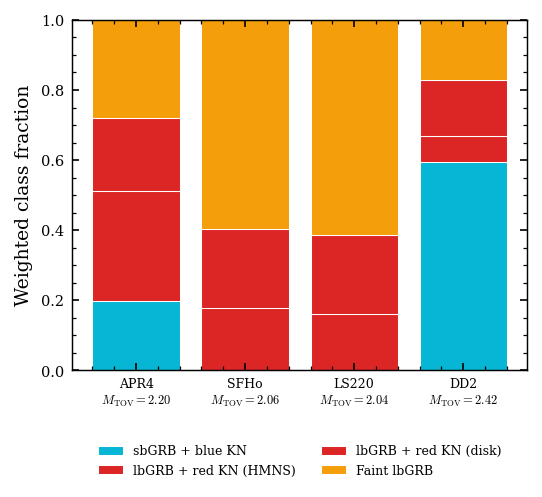


P(class | channel):
                    sbGRB + blue KN  lbGRB + red KN (HMNS)  lbGRB + red KN (disk)  Faint lbGRB
I  Classic CE                 0.716                  0.195                  0.080        0.009
II  Stable MT only            0.000                  0.000                  0.000        0.000
III Single-core CE            0.000                  0.000                  0.000        0.000
IV  Double-core CE            0.022                  0.353                  0.253        0.371
V   Other                     0.000                  0.000                  0.000        0.000


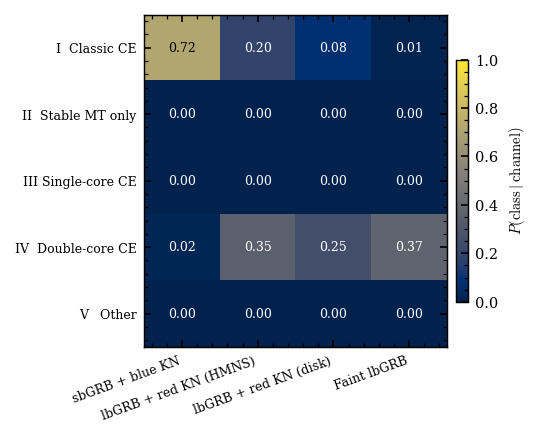

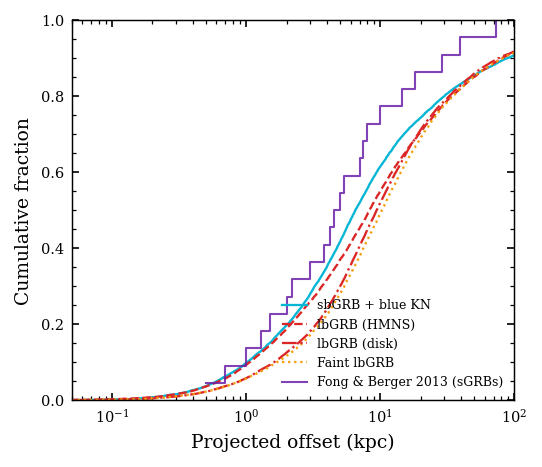


                        R_intrinsic  theta_j_deg  f_beam  R_beamed  R_obs  R_obs_lo  R_obs_hi                                                  reference
class                                                                                                                                                  
sbGRB + blue KN             11.436       13.000   0.026     0.293  3.600     1.800     6.500                                 Colombo+ 2022, ApJ 937, 79
lbGRB + red KN (HMNS)       16.618        6.500   0.006     0.107  1.300     0.500     3.000                              Ghirlanda+ 2016, A&A 594, A84
lbGRB + red KN (disk)        2.328        6.500   0.006     0.015  1.000     0.300     2.000  Levina+ 2026, arXiv:2601.20202 (per-class split estimate)
Faint lbGRB                  3.004        6.500   0.006     0.019    NaN       NaN       NaN                                 No published observed rate


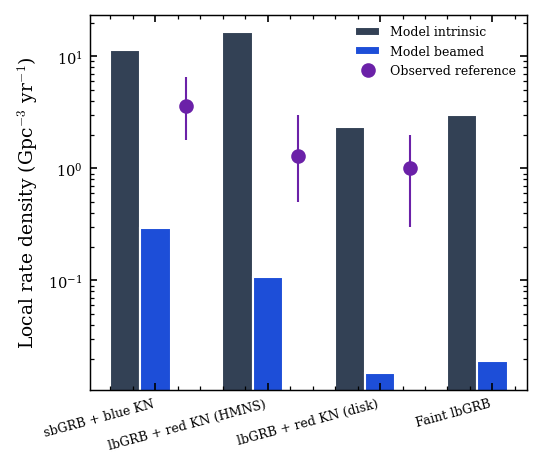

In [24]:
from grb_rates import (compute_eos_sensitivity, beamed_class_comparison,
                        OBSERVED_RATES_BY_CLASS)
from grb_classify import channel_class_crosstab
from grb_offsets import weighted_offset_cdf, OBSERVED_SGRB_OFFSETS_KPC

# 11.1 EOS sensitivity: class fractions vs M_TOV across EOS_MODELS, with
# k_thresh fixed so M_thresh = k_thresh * M_TOV (CLAUDE.md EOS coherence).
eos_table = compute_eos_sensitivity(bns_ch['m1'], bns_ch['m2'], bns_ch['weights'])
print(eos_table.to_string(float_format='{:.4f}'.format))

class_keys_eos = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                  'lbGRB + red KN (disk)', 'Faint lbGRB']
class_colors_eos = [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT]

fig1, ax = plt.subplots(figsize=(3.5, 3.2), constrained_layout=True)
x = np.arange(len(eos_table.index))
bottom = np.zeros(len(eos_table.index))
for label, color in zip(class_keys_eos, class_colors_eos):
    vals = eos_table[label].to_numpy()
    ax.bar(x, vals, bottom=bottom, color=color, label=label,
           edgecolor='white', linewidth=0.5)
    bottom = bottom + vals
ax.set_xticks(x)
ax.set_xticklabels([f"{name}\n$M_{{\\rm TOV}}={eos_table.loc[name, 'M_TOV']:.2f}$"
                    for name in eos_table.index], fontsize=6)
ax.set_ylabel('Weighted class fraction')
ax.set_ylim(0, 1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          fontsize=6, frameon=False)
fig1.savefig('Plots/eos_sensitivity.pdf')
fig1.savefig('Plots/eos_sensitivity.png', dpi=300)
plt.show()

# 11.2 Channel x class contingency table + heatmap (P(class | channel)).
cls_bns_2024 = classify_bns_2024(bns_ch['m1'], bns_ch['m2'])
crosstab_norm = channel_class_crosstab(channels, cls_bns_2024,
                                       bns_ch['weights'], normalise='channel')
crosstab_raw  = channel_class_crosstab(channels, cls_bns_2024,
                                       bns_ch['weights'])
print('\nP(class | channel):')
print(crosstab_norm.to_string(float_format='{:.3f}'.format))
crosstab_raw.to_csv('Plots/channels_x_classes.csv', float_format='%.6e')

fig2, ax = plt.subplots(figsize=(3.5, 2.8), constrained_layout=True)
im = ax.imshow(crosstab_norm.to_numpy(), cmap='cividis', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(np.arange(len(crosstab_norm.columns)))
ax.set_xticklabels(crosstab_norm.columns, rotation=20, ha='right', fontsize=6)
ax.set_yticks(np.arange(len(crosstab_norm.index)))
ax.set_yticklabels(crosstab_norm.index, fontsize=6)
for i in range(crosstab_norm.shape[0]):
    for j in range(crosstab_norm.shape[1]):
        ax.text(j, i, f"{crosstab_norm.iat[i, j]:.2f}",
                ha='center', va='center',
                color='white' if crosstab_norm.iat[i, j] < 0.5 else 'black',
                fontsize=6)
cbar = fig2.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label(r'$P(\mathrm{class}\mid\mathrm{channel})$', fontsize=7)
fig2.savefig('Plots/channels_x_classes.pdf')
fig2.savefig('Plots/channels_x_classes.png', dpi=300)
plt.show()

# 11.3 Per-class offset CDFs (Council L4): isolates the per-class curves
# already embedded in Section 9 panel 1 so they can be cited as a single
# stand-alone figure.
style_by_class = {
    'sbGRB + blue KN': (C_SB_BLUE, '-'),
    'lbGRB (HMNS)':    (C_LB_HMNS, '--'),
    'lbGRB (disk)':    (C_LB_DISK, '-.'),
    'Faint lbGRB':     (C_FAINT,   ':'),
}
fig3, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
for label, (color, ls) in style_by_class.items():
    if label not in bns_offset_results:
        continue
    o, w = bns_offset_results[label]
    x_kpc, cdf = weighted_offset_cdf(o, w)
    if x_kpc.size > 1:
        ax.step(x_kpc, cdf, where='post', color=color, ls=ls, label=label, lw=1.1)
obs_sorted = np.sort(OBSERVED_SGRB_OFFSETS_KPC)
obs_cdf    = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
ax.step(obs_sorted, obs_cdf, where='post', color=C_OBS,
        label='Fong & Berger 2013 (sGRBs)', lw=1.0, alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel(r'Projected offset (kpc)')
ax.set_ylabel('Cumulative fraction')
ax.set_xlim(0.05, 100)
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=6, frameon=False)
fig3.savefig('Plots/offset_cdf_by_class.pdf')
fig3.savefig('Plots/offset_cdf_by_class.png', dpi=300)
plt.show()

# 11.4 Per-class beamed comparator (Council L7).
R_intrinsic_by_class = {
    'sbGRB + blue KN':       float(merger_rates_BNS['sbGRB + blue KN'][iz0]),
    'lbGRB + red KN (HMNS)': float(merger_rates_BNS['lbGRB (HMNS)'][iz0]),
    'lbGRB + red KN (disk)': float(merger_rates_BNS['lbGRB (disk)'][iz0]),
    'Faint lbGRB':           float(merger_rates_BNS['Faint lbGRB'][iz0]),
}
cmp_table = beamed_class_comparison(R_intrinsic_by_class)
print('\n', cmp_table.to_string(float_format='{:.3f}'.format))

labels = list(R_intrinsic_by_class.keys())
x = np.arange(len(labels))
fig4, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
width = 0.27
ax.bar(x - width, cmp_table['R_intrinsic'].values, width=width,
       color=C_NO_GRB, label='Model intrinsic', edgecolor='white')
ax.bar(x,         cmp_table['R_beamed'].values,    width=width,
       color='#1D4ED8', label='Model beamed', edgecolor='white')
obs_central = cmp_table['R_obs'].values
obs_err = np.vstack([cmp_table['R_obs'].values - cmp_table['R_obs_lo'].values,
                     cmp_table['R_obs_hi'].values - cmp_table['R_obs'].values])
ax.errorbar(x + width, obs_central, yerr=obs_err, fmt='o', color=C_OBS,
            label='Observed reference')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=6)
ax.set_ylabel(r'Local rate density (Gpc$^{-3}$ yr$^{-1}$)')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=6, frameon=False)
fig4.savefig('Plots/beamed_class_comparison.pdf')
fig4.savefig('Plots/beamed_class_comparison.png', dpi=300)
plt.show()
